# Computer Vision Assignment 1 — Question 4
## Edge Detection and Analysis

This notebook implements:
1. First-order derivatives in x and y directions
2. Gradient magnitude and direction
3. Binary edge maps using three thresholds
4. Second-order derivative edge detection
5. Laplacian of Gaussian (LoG) and Canny edge detection
6. Final comparison of all methods


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import cv2
from skimage import data
import time


## 1. Manual Convolution

In [6]:
# Manual convolution
def manual_convolution(image, kernel):
    image = image.astype(np.float64)

    kh, kw = kernel.shape
    ph = kh // 2
    pw = kw // 2

    padded = np.pad(
        image,
        ((ph, ph), (pw, pw)),
        mode='reflect'
    )

    output = np.zeros_like(image, dtype=np.float64)

    for i in range(image.shape[0]):
        for j in range(image.shape[1]):
            region = padded[i:i+kh, j:j+kw]
            output[i, j] = np.sum(region * kernel)

    return output


## 2. First-Order Derivatives

In [7]:
# X and Y derivative kernels

Kx = np.array([
    [-1, 0, 1],
    [-2, 0, 2],
    [-1, 0, 1]
], dtype=np.float64)

Ky = np.array([
    [-1, -2, -1],
    [ 0,  0,  0],
    [ 1,  2,  1]
], dtype=np.float64)


def first_order_derivatives(img):
    Gx = manual_convolution(img, Kx)
    Gy = manual_convolution(img, Ky)
    return Gx, Gy


In [8]:
def show_derivatives(img, gx, gy, title):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(np.abs(gx), cmap='gray')
    plt.title("X-Direction Derivative |Gx|")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(np.abs(gy), cmap='gray')
    plt.title("Y-Direction Derivative |Gy|")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


## 3. Load the Two Grayscale Images

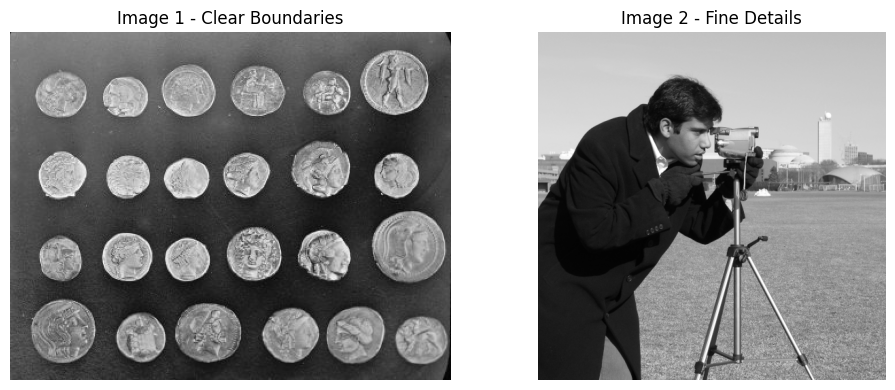

In [9]:
# Image 1: clearly defined object boundaries
img1 = data.coins()

# Image 2: image containing fine details
img2 = data.camera()

img1 = img1.astype(np.uint8)
img2 = img2.astype(np.uint8)

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
plt.imshow(img1, cmap='gray')
plt.title("Image 1 - Clear Boundaries")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(img2, cmap='gray')
plt.title("Image 2 - Fine Details")
plt.axis("off")

plt.tight_layout()
plt.show()


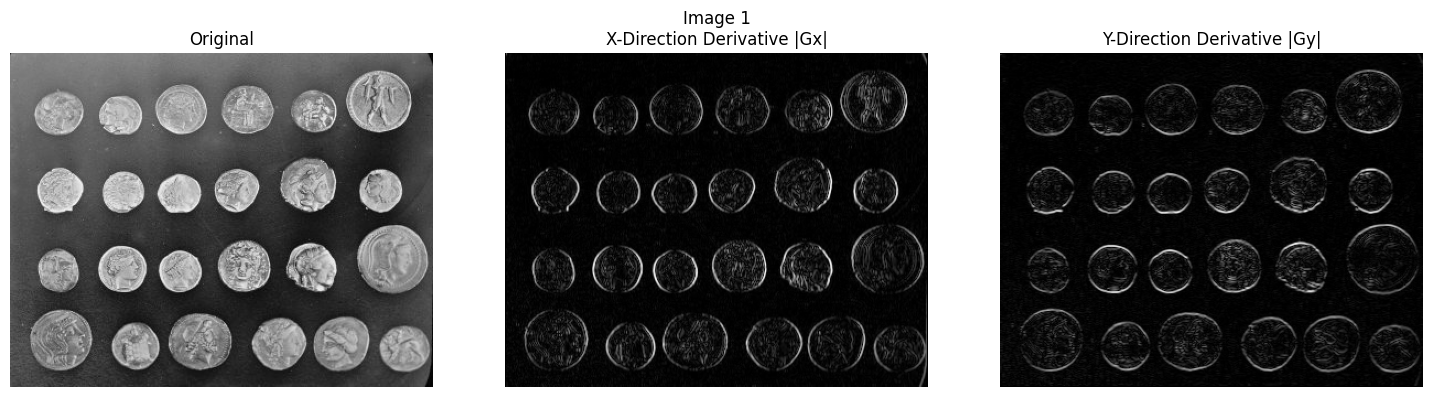

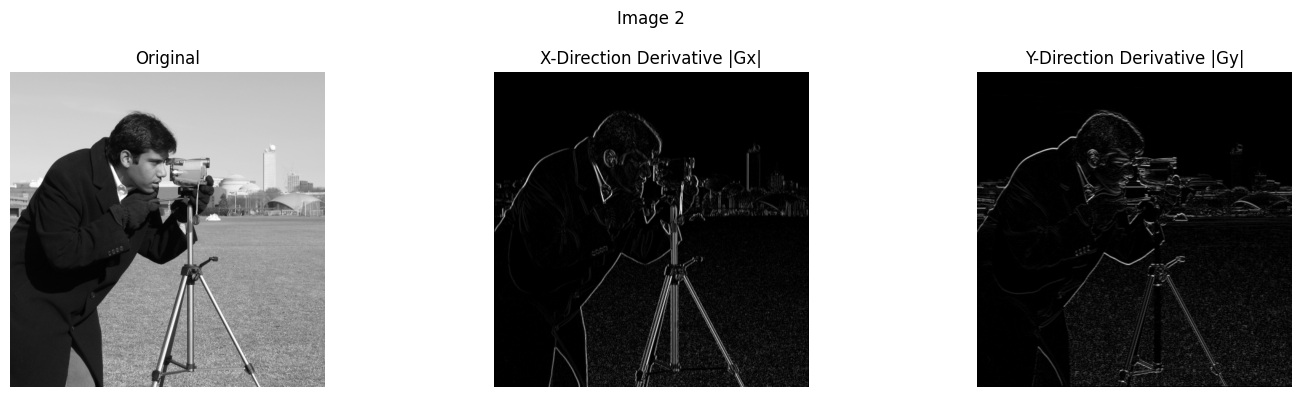

In [10]:
gx1, gy1 = first_order_derivatives(img1)
gx2, gy2 = first_order_derivatives(img2)

show_derivatives(img1, gx1, gy1, "Image 1")
show_derivatives(img2, gx2, gy2, "Image 2")


## 4. Gradient Magnitude and Direction

In [11]:
def gradient_information(gx, gy):
    magnitude = np.sqrt(gx**2 + gy**2)
    direction = np.arctan2(gy, gx)
    return magnitude, direction


mag1, direction1 = gradient_information(gx1, gy1)
mag2, direction2 = gradient_information(gx2, gy2)


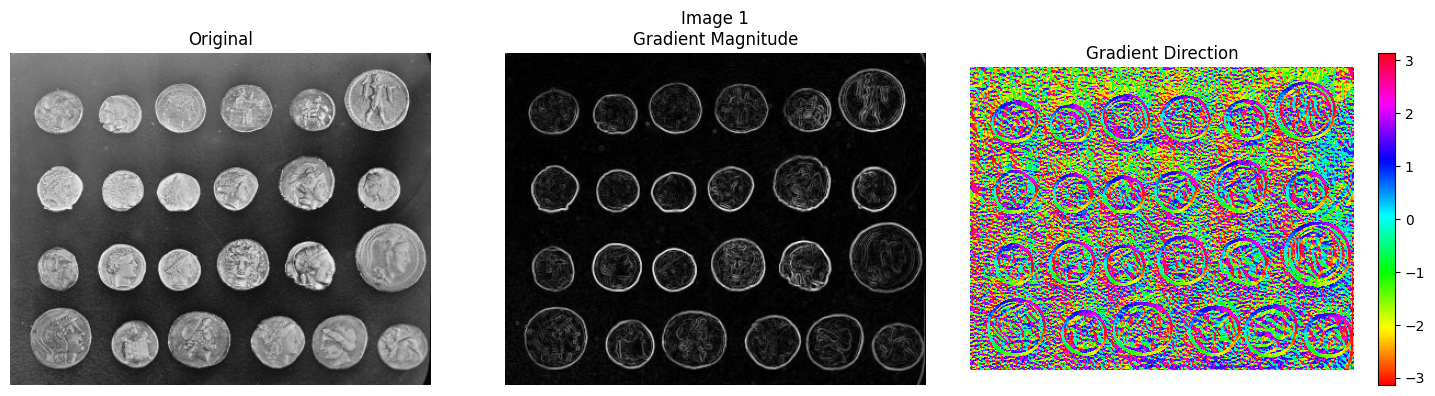

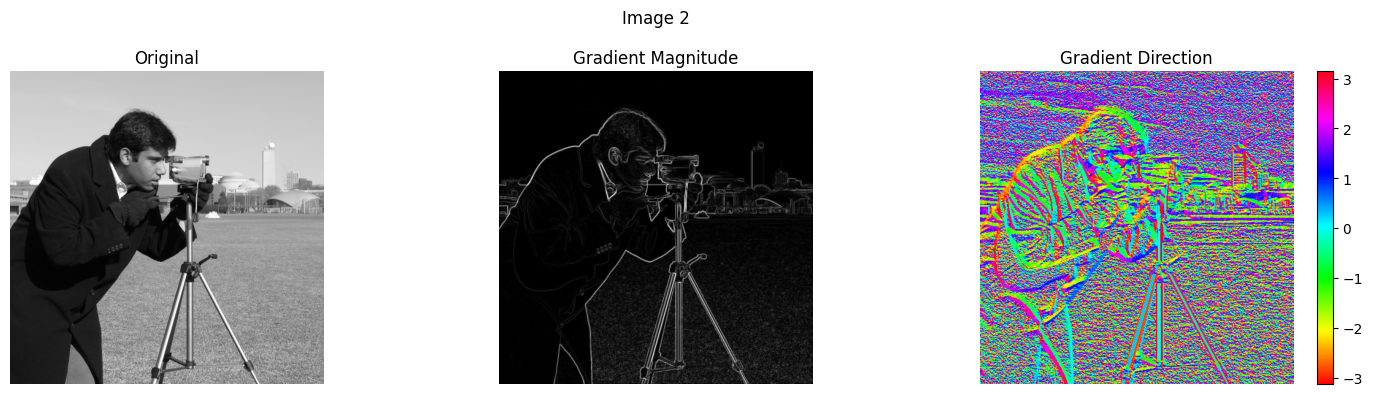

In [12]:
def show_gradient(img, magnitude, direction, title):
    plt.figure(figsize=(15, 4))

    plt.subplot(1, 3, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 3, 2)
    plt.imshow(magnitude, cmap='gray')
    plt.title("Gradient Magnitude")
    plt.axis("off")

    plt.subplot(1, 3, 3)
    plt.imshow(direction, cmap='hsv')
    plt.title("Gradient Direction")
    plt.colorbar()
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_gradient(img1, mag1, direction1, "Image 1")
show_gradient(img2, mag2, direction2, "Image 2")


## 5. Binary Edge Maps Using Three Thresholds

In [13]:
def generate_threshold_edges(magnitude):
    max_mag = np.max(magnitude)

    thresholds = [
        0.10 * max_mag,
        0.20 * max_mag,
        0.30 * max_mag
    ]

    edges = []

    for t in thresholds:
        edge = np.zeros_like(magnitude, dtype=np.uint8)
        edge[magnitude >= t] = 255
        edges.append(edge)

    return thresholds, edges


thresholds1, edges1 = generate_threshold_edges(mag1)
thresholds2, edges2 = generate_threshold_edges(mag2)


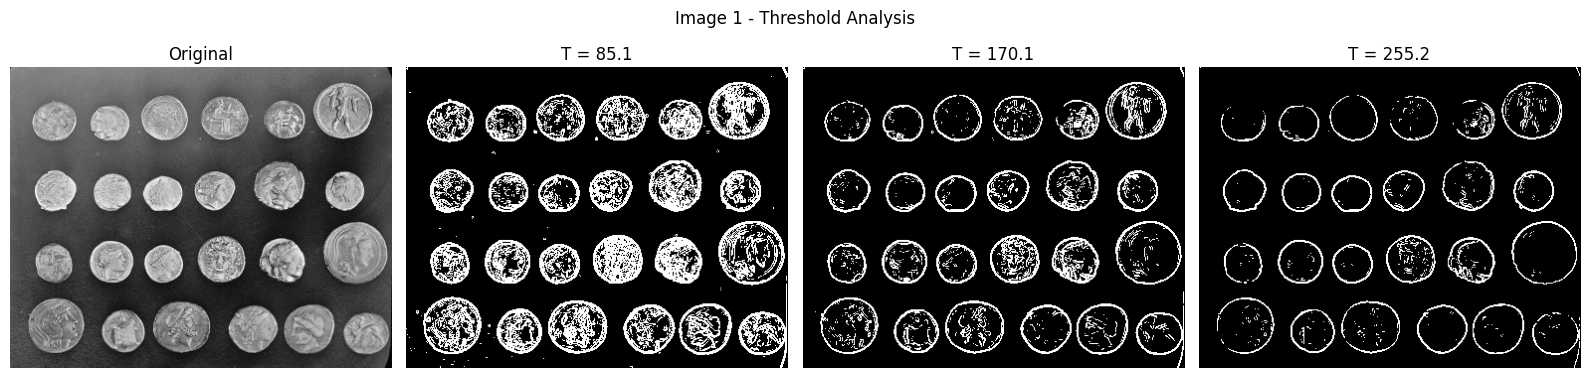

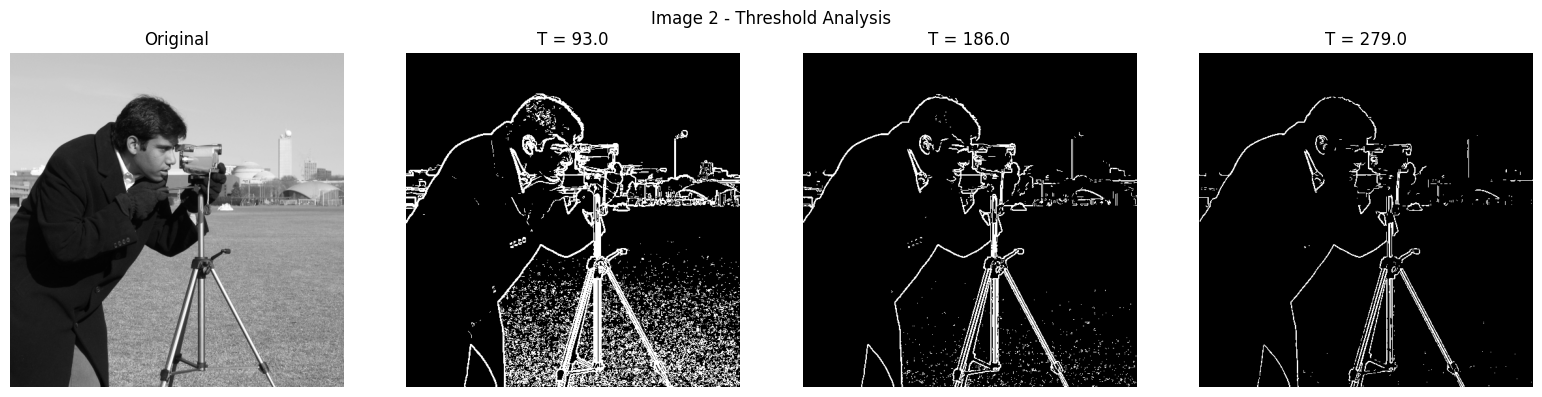

In [14]:
def show_thresholds(img, thresholds, edges, title):
    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    for i in range(3):
        plt.subplot(1, 4, i + 2)
        plt.imshow(edges[i], cmap='gray')
        plt.title(f"T = {thresholds[i]:.1f}")
        plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


show_thresholds(img1, thresholds1, edges1, "Image 1 - Threshold Analysis")
show_thresholds(img2, thresholds2, edges2, "Image 2 - Threshold Analysis")


### Threshold Observation

- **Low threshold:** detects weak edges and fine details, but also introduces unwanted edges.
- **Medium threshold:** provides a good compromise between edge preservation and noise suppression.
- **High threshold:** retains only strong boundaries but may miss weak or fine edges.


## 6. Second-Order Derivative

In [15]:
laplacian_kernel = np.array([
    [0,  1, 0],
    [1, -4, 1],
    [0,  1, 0]
], dtype=np.float64)


def second_order_derivative(img):
    return manual_convolution(img, laplacian_kernel)


lap1 = second_order_derivative(img1)
lap2 = second_order_derivative(img2)


def laplacian_edge_map(lap):
    abs_lap = np.abs(lap)

    threshold = 0.15 * np.max(abs_lap)

    edge = np.zeros_like(abs_lap, dtype=np.uint8)
    edge[abs_lap >= threshold] = 255

    return edge


lap_edge1 = laplacian_edge_map(lap1)
lap_edge2 = laplacian_edge_map(lap2)


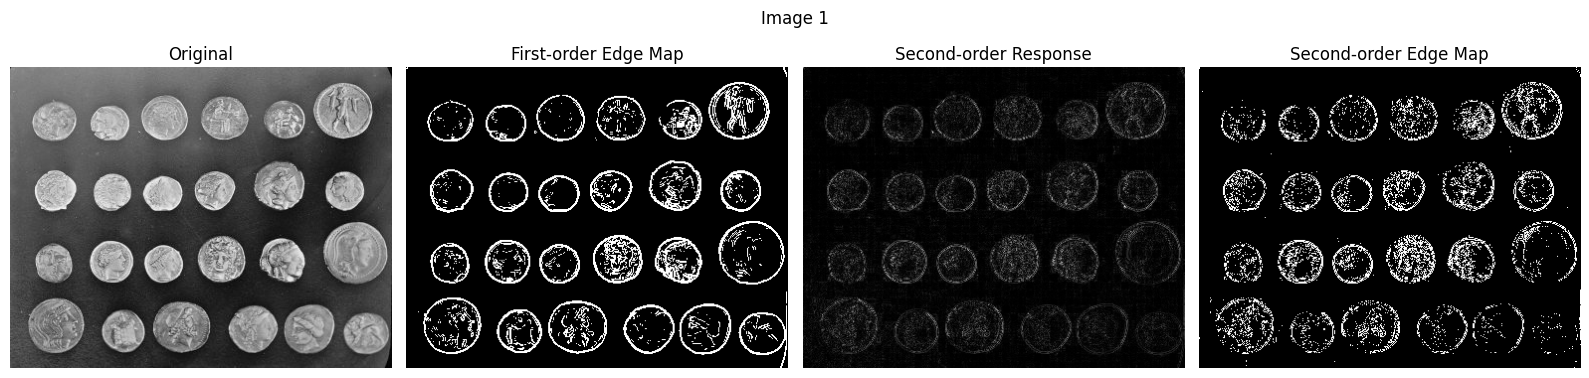

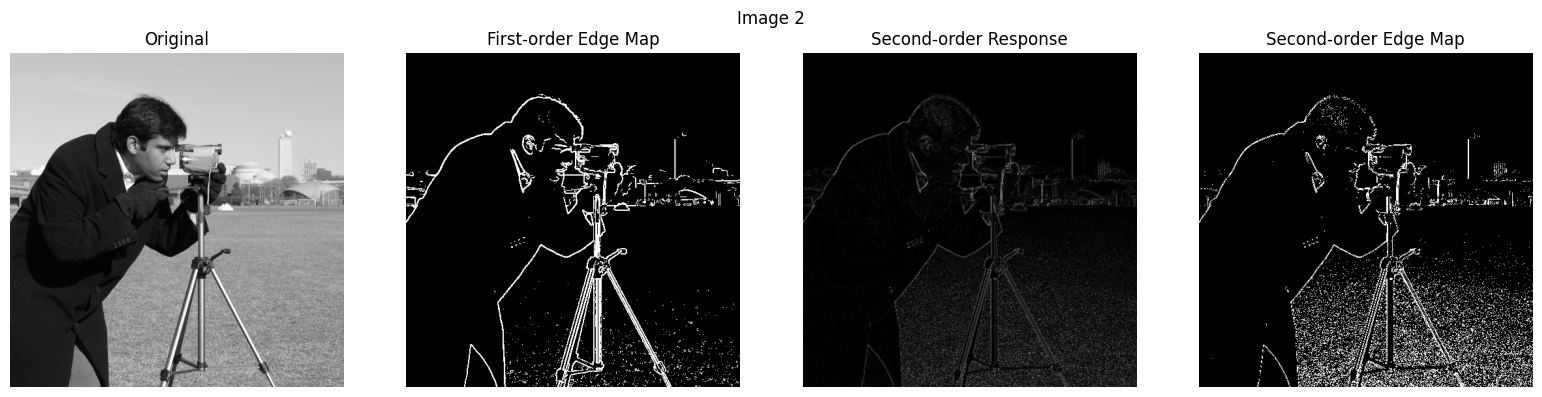

In [16]:
def compare_first_second(img, magnitude, lap, lap_edge, title):
    first_edge = np.zeros_like(magnitude, dtype=np.uint8)
    first_edge[magnitude >= 0.20*np.max(magnitude)] = 255

    plt.figure(figsize=(16, 4))

    plt.subplot(1, 4, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 4, 2)
    plt.imshow(first_edge, cmap='gray')
    plt.title("First-order Edge Map")
    plt.axis("off")

    plt.subplot(1, 4, 3)
    plt.imshow(np.abs(lap), cmap='gray')
    plt.title("Second-order Response")
    plt.axis("off")

    plt.subplot(1, 4, 4)
    plt.imshow(lap_edge, cmap='gray')
    plt.title("Second-order Edge Map")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


compare_first_second(img1, mag1, lap1, lap_edge1, "Image 1")
compare_first_second(img2, mag2, lap2, lap_edge2, "Image 2")


## 7. Laplacian of Gaussian (LoG)

In [17]:
def log_detector(img, sigma=1.4):
    blurred = cv2.GaussianBlur(
        img,
        (5, 5),
        sigmaX=sigma,
        sigmaY=sigma
    )

    log_response = manual_convolution(
        blurred,
        laplacian_kernel
    )

    return log_response


def zero_crossing(log_img, threshold=5):
    h, w = log_img.shape
    output = np.zeros((h, w), dtype=np.uint8)

    for i in range(1, h - 1):
        for j in range(1, w - 1):
            region = log_img[i-1:i+2, j-1:j+2]

            minimum = region.min()
            maximum = region.max()

            if minimum < 0 and maximum > 0:
                if maximum - minimum > threshold:
                    output[i, j] = 255

    return output


log1 = log_detector(img1)
log2 = log_detector(img2)

log_edge1 = zero_crossing(log1, threshold=5)
log_edge2 = zero_crossing(log2, threshold=5)


## 8. Canny Edge Detector

In [18]:
canny1 = cv2.Canny(img1, 70, 150)
canny2 = cv2.Canny(img2, 70, 150)


## 9. Final Comparison

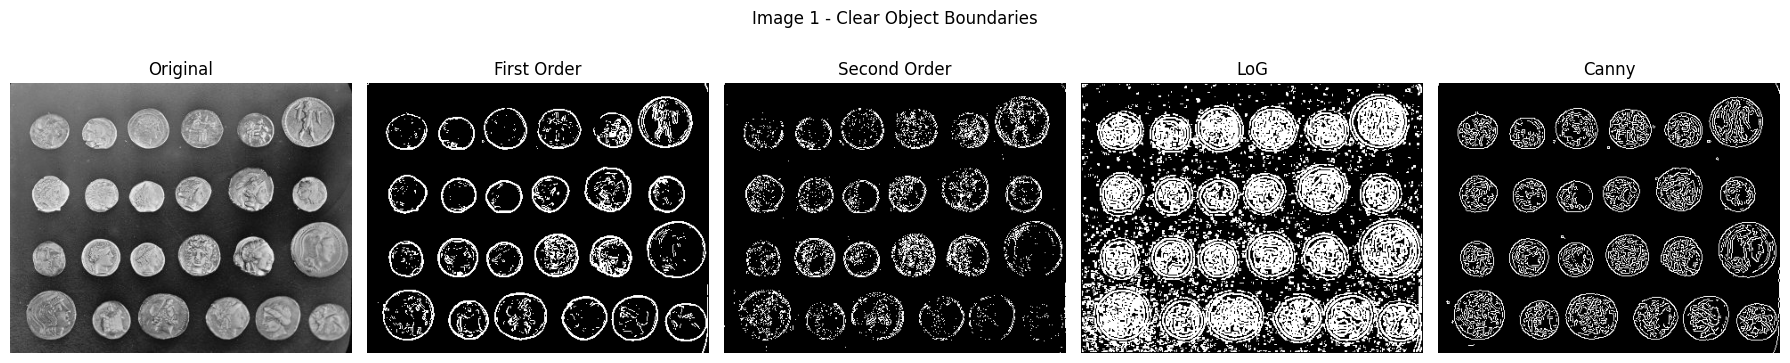

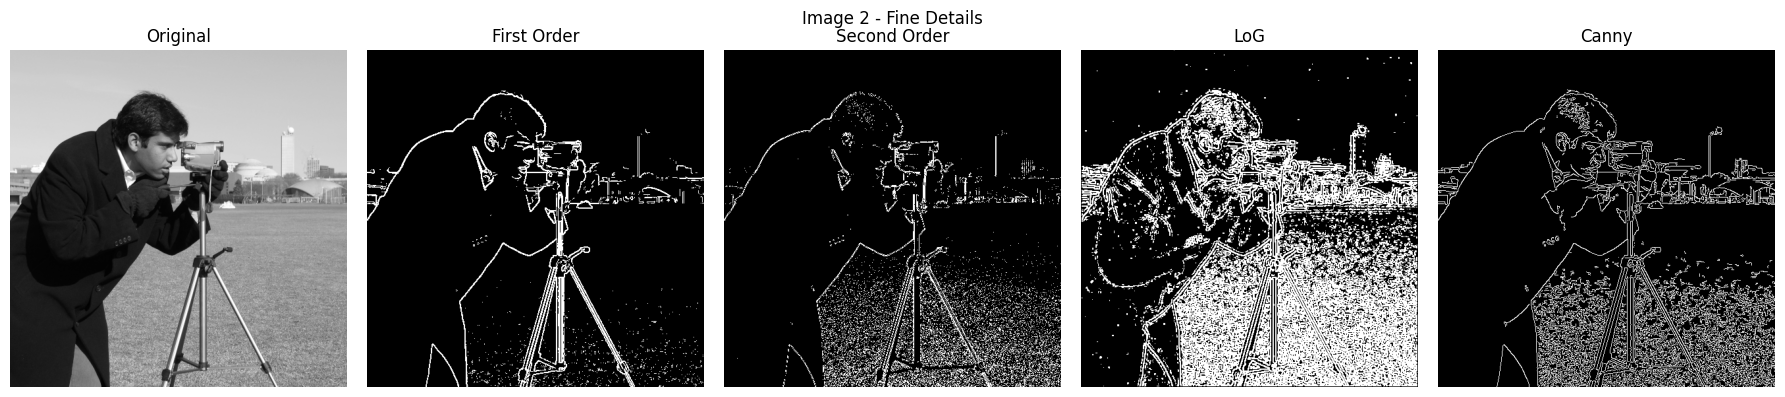

In [19]:
def final_comparison(img, magnitude, lap_edge, log_edge, canny, title):
    grad_edge = np.zeros_like(magnitude, dtype=np.uint8)
    grad_edge[magnitude >= 0.20*np.max(magnitude)] = 255

    plt.figure(figsize=(18, 4))

    plt.subplot(1, 5, 1)
    plt.imshow(img, cmap='gray')
    plt.title("Original")
    plt.axis("off")

    plt.subplot(1, 5, 2)
    plt.imshow(grad_edge, cmap='gray')
    plt.title("First Order")
    plt.axis("off")

    plt.subplot(1, 5, 3)
    plt.imshow(lap_edge, cmap='gray')
    plt.title("Second Order")
    plt.axis("off")

    plt.subplot(1, 5, 4)
    plt.imshow(log_edge, cmap='gray')
    plt.title("LoG")
    plt.axis("off")

    plt.subplot(1, 5, 5)
    plt.imshow(canny, cmap='gray')
    plt.title("Canny")
    plt.axis("off")

    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


final_comparison(
    img1, mag1, lap_edge1,
    log_edge1, canny1,
    "Image 1 - Clear Object Boundaries"
)

final_comparison(
    img2, mag2, lap_edge2,
    log_edge2, canny2,
    "Image 2 - Fine Details"
)


## 10. Comparison and Conclusion

| Method | Edge Localization | Continuity | Thickness | Fine Details | Noise Sensitivity |
|---|---|---|---|---|---|
| First-order gradient | Good | Moderate | Relatively thick | Good | Moderate |
| Second-order Laplacian | Good | Often fragmented | Thin / possible double edges | Very high | High |
| LoG | Good | Good | Thin | Good | Lower than Laplacian |
| Canny | Excellent | Excellent | Thin | Excellent | Low |

### Conclusion

For the image containing clearly defined object boundaries, the **Canny edge detector** gives the most suitable result because it provides thin, well-localized and continuous edges while suppressing unwanted responses.

For the fine-detail image, Canny again gives the best overall result because it preserves important fine structures while reducing noisy edges.

The first-order gradient detects useful boundaries but tends to produce thicker edges. The second-order Laplacian is highly sensitive to rapid intensity changes and therefore may detect excessive fine structure and noise. LoG improves the second-order result by smoothing the image before applying the Laplacian.

Increasing the threshold reduces unwanted edges but can cause weak edges to disappear. Decreasing the threshold preserves weak and fine edges but increases false detections.
